In [17]:
import os,sys
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
from plotnine import *
from functools import reduce
from pathlib import Path
import re
import glob
import matplotlib.pyplot as plt

In [282]:
def classify_sgrna(df):
    df['sgRNA_type'] = 'single sgRNA'
    # overwrite where gRNA is missing
    df.loc[df['guide_id'].isna(), 'sgRNA_type'] = 'no sgRNA'
    df.loc[df['guide_id'].str.startswith('NTC', na=False), 'sgRNA_type'] = 'single NTC sgRNA'
    df.loc[df['guide_id'].str.startswith('multi', na=False), 'sgRNA_type'] = 'multi sgRNA'
    # Order the rows
    type_order = ['single sgRNA','single NTC sgRNA','multi sgRNA','no sgRNA']
    df['sgRNA_type'] = pd.Categorical(df['sgRNA_type'],categories=type_order,ordered=True)
    # df = df.loc[:, ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
                    # 'gRNA', 'guide_id', 'UMI_counts', 'target_gene','sgRNA_type']]
    return df

In [24]:
def plot_lane_sgRNA(df):
    p = (
        ggplot(df, aes(x = 'condition', fill = 'sgRNA_type'))
        + geom_bar(position="stack")
        + scale_fill_brewer(type='sequential', palette= 5, direction= -1)
        + labs(x = 'Condition',
              y = 'Cell counts')
        + theme_bw()
        + theme(figure_size=(5, 3),
                legend_title=element_blank(),
                axis_text_x=element_text(rotation=90, 
                                         hjust=1))
        + theme(
            plot_title=element_text(size=16, face="bold", ha='center'),
            axis_title_x=element_text(size=18),
            axis_title_y=element_text(size=18),
            axis_text_x=element_text(size=10),
            axis_text_y=element_text(size=10)
            )
        )
    return p

In [25]:
path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/macs_perturbseq_analysis'
files = [file for file in os.listdir(path) if file.startswith('Mac_')]
files = sorted(files)
files

['Mac_L01_Mac_Ctrl',
 'Mac_L01_Mac_LPS',
 'Mac_L02_Mac_Ctrl',
 'Mac_L02_Mac_LPS',
 'Mac_L03_Mac_Ctrl',
 'Mac_L03_Mac_LPS',
 'Mac_L04_Mac_Ctrl',
 'Mac_L04_Mac_LPS']

In [283]:
df1 = pd.DataFrame()
for i in range(0,len(files)):
    df = pd.DataFrame()
    path = f'/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/macs_perturbseq_analysis/{files[i]}/'
    guide_pattern = glob.glob(os.path.join(path, "*_gex_guide.h5ad"))[0]
    # print(guide_pattern)
    adata = sc.read_h5ad(guide_pattern)
    df = adata.obs
    df_guide = classify_sgrna(df)
    df_guide['experiment'] = files[i]
    #     df = pd.concat([df, df_guide])
    df1 = pd.concat([df1, df_guide])

In [188]:
df1['condition'] = df1['experiment'].apply(lambda x: ' '.join(x.split('_')[2:4]))
df1.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,gRNA,guide_id,UMI_counts,target_gene,sgRNA_type,experiment,condition
AAACAAGCAAACAATCAACGGGAA-1_Mac_Ctrl_Mac_L01,3810,8.245647,10902.0,HIST1H3G-1,HIST1H3G-1,149.0,HIST1H3G,single sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCAAACAATCAAGTAGAG-1_Mac_Ctrl_Mac_L01,3648,8.202208,11141.0,ITPA-4,multi_sgRNA,184.0,multi_sgRNA,multi sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCAAACCGTAAACGGGAA-1_Mac_Ctrl_Mac_L01,3660,8.205492,8691.0,NTC-453,multi_sgRNA,37.0,multi_sgRNA,multi sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCAAAGAACAACTTTAGG-1_Mac_Ctrl_Mac_L01,3879,8.263590,12200.0,TRAPPC9-2,multi_sgRNA,30.0,multi_sgRNA,multi sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCAAAGCTCAAACGGGAA-1_Mac_Ctrl_Mac_L01,3406,8.133587,8737.0,GSDMC-1,multi_sgRNA,95.0,multi_sgRNA,multi sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl


In [13]:
qc_path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/macs_perturbseq_analysis/qc_stats'
os.makedirs(qc_path, exist_ok= True)
df1.to_csv(os.path.join(qc_path, 'metadata_all_lane_qc.csv'))

In [19]:
plt_path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/macs_perturbseq_analysis/plots'
# os.makedirs(plt_path, exist_ok= True)
# plt_c = plot_lane_sgRNA(df1)
# plt_c = plt_c + theme(
#     panel_grid_major = element_blank(),
#     panel_grid_minor = element_blank(),
#     axis_text_x=element_text(size=14),
#     axis_text_y=element_text(size=14),
#     legend_text=element_text(size=12),
#     figure_size = (5, 5)
# )
# plt_c.save(os.path.join(plt_path, 'sgRNA_type_distribution.pdf'), dpi= 300)
# plt_c.show()

# 

# Expression Pattern of all the cells

In [171]:
df1.groupby(['condition', 'sgRNA_type']).size()

/var/folders/lh/8shkr2ln1lz628fhh9nfhqh00000gp/T/ipykernel_84119/1295668211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


condition  sgRNA_type      
Mac Ctrl   single sgRNA         89111
           single NTC sgRNA     23309
           multi sgRNA         458416
           no sgRNA              3784
Mac LPS    single sgRNA         99161
           single NTC sgRNA     25783
           multi sgRNA         549525
           no sgRNA              3998
dtype: int64

In [7]:
adatas = []
for i in range(0,len(files)):
    df = pd.DataFrame()
    path = f'/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/macs_perturbseq_analysis/{files[i]}/'
    guide_pattern = glob.glob(os.path.join(path, "*_gex_guide.h5ad"))[0]
    # print(guide_pattern)
    adata = sc.read_h5ad(guide_pattern)
    adata = adata[adata.obs.guide_id.str.startswith('NTC',  na=False)].copy()
    # sc.pp.normalize_total(adata)
    # sc.pp.log1p(adata)
    adatas.append(adata)

In [12]:
import anndata
adata_merge = anndata.concat(adatas, join='outer') 

In [13]:
# Run the split/join on the merged object itself
adata_merge.obs['condition'] = adata_merge.obs['lane_id'].apply(lambda x : ' '.join(x.split('_')))
adata_merge.obs

,library_id,lane_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes,gRNA,guide_id,target_gene,UMI_counts,condition
AAACAAGCATCAGGTAATCCCAAC-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3260,8.089789,7972.0,8.983816,24.071751,30.406422,38.183643,52.458605,1.0,0.693147,0.012544,3260,NTC-455,NTC-455,NTC,21.0,Mac Ctrl
AAACCAATCAACCGGAACTTTAGG-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3799,8.242756,10048.0,9.215228,23.477309,29.727309,37.400478,51.323646,20.0,3.044523,0.199045,3799,NTC-017,NTC-017,NTC,93.0,Mac Ctrl
AAACCAATCACCTTTCAGTAGGCT-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3804,8.244071,9874.0,9.197762,24.772129,30.919587,38.353251,51.914118,2.0,1.098612,0.020255,3804,NTC-125,NTC-125,NTC,68.0,Mac Ctrl
AAACCAATCTATCGGCACAGACCT-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3927,8.275886,11213.0,9.324919,25.408009,31.909391,39.757424,52.974226,8.0,2.197225,0.071346,3927,NTC-400,NTC-400,NTC,107.0,Mac Ctrl
AAACCAATCTCAAACTAAGTAGAG-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,4647,8.444192,15046.0,9.618934,26.990562,33.098498,40.422704,52.585405,21.0,3.091043,0.139572,4647,NTC-330,NTC-330,NTC,33.0,Mac Ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGCGGTAGGAGGAATCATGTG-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,4634,8.441391,21409.0,9.971613,26.372087,35.031996,44.425242,58.171797,9.0,2.302585,0.042038,4634,NTC-335,NTC-335,NTC,34.0,Mac LPS
TTTGGCGGTATTCGTAACTACTCA-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,5095,8.536211,23993.0,10.085559,28.174884,35.122744,43.241779,56.099696,59.0,4.094345,0.245905,5095,NTC-158,NTC-158,NTC,37.0,Mac LPS
TTTGGCGGTGATCCTGATTCGGTT-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,5168,8.550435,22266.0,10.010861,24.957334,31.370700,39.598491,53.107877,12.0,2.564949,0.053894,5168,NTC-385,NTC-385,NTC,233.0,Mac LPS
TTTGGCGGTTGGATGAAGTGAGTG-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,4872,8.491465,16138.0,9.688994,21.229396,28.212914,36.274631,49.529062,18.0,2.944439,0.111538,4872,NTC-175,NTC-175,NTC,151.0,Mac LPS


In [14]:
vars_list = ["CD14", "CD68", "CD40",
            "IL1B", "CXCL8", "CCL2", "IL6", "CD80", "CD86", "SPP1", "MRC1", "MARCO", "CD163", "MSR1"]

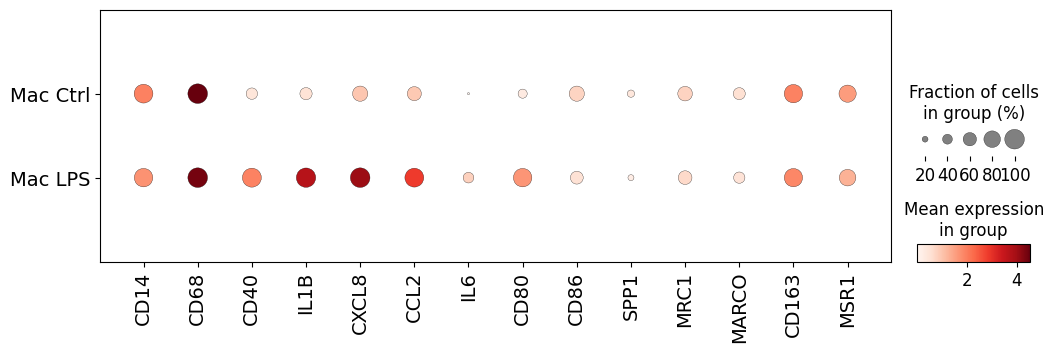

In [21]:
axes = sc.pl.dotplot(adata_merge, 
                     groupby="condition", 
                     var_names=vars_list, 
                     figsize=(12, 4),
                     show=False)

axes['mainplot_ax'].tick_params(axis='x', labelsize=14)
axes['mainplot_ax'].tick_params(axis='y', labelsize=14)
axes['color_legend_ax'].tick_params(labelsize=12)
axes['color_legend_ax'].title.set_size(12)
axes['size_legend_ax'].tick_params(labelsize=12)
axes['size_legend_ax'].title.set_size(12)

plt.subplots_adjust(bottom=0.25)  # make room for rotated labels
plt.savefig(os.path.join(plt_path, 'genes_expression_on_ntc.pdf'), 
            dpi=300, bbox_inches='tight')
plt.show()

In [15]:
adata_merge.var_names[adata_merge.var_names.str.startswith("CD6")]

Index(['CD6', 'CD69', 'CD63', 'CD68'], dtype='object')

In [322]:
df1['condition'] = df1['lane_id'].apply(lambda x : ' '.join(x.split('_')))

In [287]:
df_single =  df1[df1['sgRNA_type'].str.startswith("single")]
df_single

/var/folders/lh/8shkr2ln1lz628fhh9nfhqh00000gp/T/ipykernel_8166/3029703766.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,library_id,lane_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,log1p_total_counts_mt,pct_counts_mt,n_genes,gRNA,guide_id,target_gene,UMI_counts,sgRNA_type,experiment,condition
AAACAAGCAAACAATCAACGGGAA-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3810,8.245647,10902.0,9.296793,24.784443,31.269492,39.497340,53.384700,...,1.945910,0.055036,3810,HIST1H3G-1,HIST1H3G-1,HIST1H3G,149.0,single sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCAACAGGGAACAGACCT-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,4146,8.330140,10480.0,9.257319,20.496183,26.250000,33.711832,47.290076,...,1.945910,0.057252,4146,GHITM-2,GHITM-2,GHITM,173.0,single sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCAATACTGGAGCTGTGA-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3748,8.229244,9979.0,9.208339,25.132779,31.566289,39.272472,52.730735,...,1.609438,0.040084,3748,SLC4A1-4,SLC4A1-4,SLC4A1,31.0,single sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCACACTGGGAAGTAGAG-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3611,8.192017,9956.0,9.206031,26.516673,33.065488,40.709120,54.359180,...,1.386294,0.030133,3611,TGFBR1-1,TGFBR1-1,TGFBR1,97.0,single sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
AAACAAGCACTTTATGAAGTAGAG-1_Mac_Ctrl_Mac_L01,Mac_L01,Mac_Ctrl,3828,8.250359,10266.0,9.236691,24.439899,30.839665,38.408338,52.230664,...,1.609438,0.038964,3828,UQCR10-1,UQCR10-1,UQCR10,155.0,single sgRNA,Mac_L01_Mac_Ctrl,Mac Ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGAGTGACCTATATTCGGTT-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,5635,8.636930,27813.0,10.233294,25.124942,32.128861,40.437925,54.021501,...,2.708050,0.050336,5635,CD36-3,CD36-3,CD36,212.0,single sgRNA,Mac_L04_Mac_LPS,Mac LPS
TTTGTGAGTGGTTCGCATTCGGTT-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,5913,8.685078,34564.0,10.450597,28.442889,35.317093,43.403541,56.321606,...,2.564949,0.034718,5913,NTC-494,NTC-494,NTC,32.0,single NTC sgRNA,Mac_L04_Mac_LPS,Mac LPS
TTTGTGAGTGTGAGACACTACTCA-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,5740,8.655389,28731.0,10.265767,27.774877,34.624621,42.351467,54.766628,...,2.639057,0.045247,5740,HDAC3-2,HDAC3-2,HDAC3,51.0,single sgRNA,Mac_L04_Mac_LPS,Mac LPS
TTTGTGAGTTCACTCCATCATGTG-1_Mac_LPS_Mac_L04,Mac_L04,Mac_LPS,5403,8.594895,21433.0,9.972733,24.014370,30.793636,38.226100,50.856156,...,3.295837,0.121308,5403,RAB18-3,RAB18-3,RAB18,183.0,single sgRNA,Mac_L04_Mac_LPS,Mac LPS


In [327]:
df_single =  df1[df1['sgRNA_type'].str.startswith("single")]
df_target = (
    df_single
    .groupby(['target_gene', 'condition'])
    .size()
    .reset_index(name='n_cells')
)

df_target.groupby('condition')['n_cells'].mean()

/var/folders/lh/8shkr2ln1lz628fhh9nfhqh00000gp/T/ipykernel_8166/636661929.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


condition
Mac Ctrl    196.882662
Mac LPS     218.816112
Name: n_cells, dtype: float64

In [ ]:
df_sgumi = pd.DataFrame()
for i in range(0,len(files)):
    df = pd.DataFrame()
    path = f'/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/macs_perturbseq_analysis/{files[i]}/'
    guide_pattern = glob.glob(os.path.join(path, "guide_assigned.csv"))[0]
    # print(guide_pattern)
    df = pd.read_csv(guide_pattern)
    # df_agg = df.groupby("cell").agg(
        # sum_sgrna_umi = ('UMI_counts', 'sum')
    # )
    df['condition'] = ' '.join(files[i].split('_')[2:4])
    #     df = pd.concat([df, df_guide])
    df_sgumi = pd.concat([df_sgumi, df])

df_sgumi['target_gene'] =  df_sgumi.gRNA.str.split('-').str[0]

In [367]:
# Step 1: Count cells for every individual gRNA
grna_coverage = df_sgumi.groupby(['target_gene', 'gRNA', 'condition']).size().reset_index(name='cell_count')

# Step 2: Average those counts across the guides for each gene
mean_cells_per_guide = grna_coverage.groupby(['target_gene', 'condition'])['cell_count'].mean().reset_index(name='mean_cells_per_guide')


,target_gene,condition,mean_cells_per_guide
0,A4GALT,Mac Ctrl,691.75
1,A4GALT,Mac LPS,833.00
2,AAGAB,Mac Ctrl,581.25
3,AAGAB,Mac LPS,704.25
4,ABCF1,Mac Ctrl,713.25
...,...,...,...
1135,ZNF79,Mac LPS,823.25
1136,ZNF823,Mac Ctrl,645.25
1137,ZNF823,Mac LPS,782.50
1138,ZNRD1,Mac Ctrl,679.25


In [392]:
# Average the UMI counts across all guides detected within each unique cell
mean_umi_per_cell = df_sgumi.groupby(['cell', 'condition'])['UMI_counts'].mean().reset_index(name='avg_sgrna_umi_per_cell')

# If you want a single summary number per condition:
condition_umi_summary = mean_umi_per_cell.groupby('condition')['avg_sgrna_umi_per_cell'].mean()
condition_umi_summary

condition
Mac Ctrl    68.998153
Mac LPS     86.596903
Name: avg_sgrna_umi_per_cell, dtype: float64

In [379]:
guide_cells_summary = mean_cells_per_guide.groupby('condition')['mean_cells_per_guide'].mean()

In [432]:
# Summary at the gRNA level including the target_gene information
# df_summary = df_sgumi.groupby(['target_gene', 'gRNA', 'condition']).agg(
#     n_cells=('cell', 'count'),
#     mean_sgumi=('UMI_counts', 'mean')
# ).reset_index()
# df_summary.groupby(['target_gene', 'condition']).agg(
#     mean_n_cells = ('n_cells', 'mean'),
#     mean_umi_cells = ('mean_sgumi', 'mean')
# )
# df_summary

In [428]:
df_raw_plot = df_single.groupby(['condition']).agg(
    # n_cells=('gRNA', 'size'),
    mean_sgRNA_assigned_UMI=('UMI_counts', 'mean'),
    mean_mito = ('pct_counts_mt', 'mean'),
    mean_UMI = ('total_counts', 'mean'),
    mean_genes = ('n_genes', 'mean')
)
df_raw_plot

,mean_sgRNA_assigned_UMI,mean_mito,mean_UMI,mean_genes
condition,,,,
Mac Ctrl,98.476532,0.089161,13947.331055,4238.536853
Mac LPS,128.867233,0.107337,15475.566406,4157.349028


In [429]:
df_combined = pd.concat([df_raw_plot, condition_umi_summary, guide_cells_summary], axis=1)
df_combined.reset_index(inplace=True)

In [426]:
df_combined

,condition,mean_sgRNA_top_UMI,mean_mito,mean_UMI,mean_genes,avg_sgrna_umi_per_cell,mean_cells_per_guide
0,Mac Ctrl,98.476532,0.089161,13947.331055,4238.536853,68.998153,650.633662
1,Mac LPS,128.867233,0.107337,15475.566406,4157.349028,86.596903,801.567142


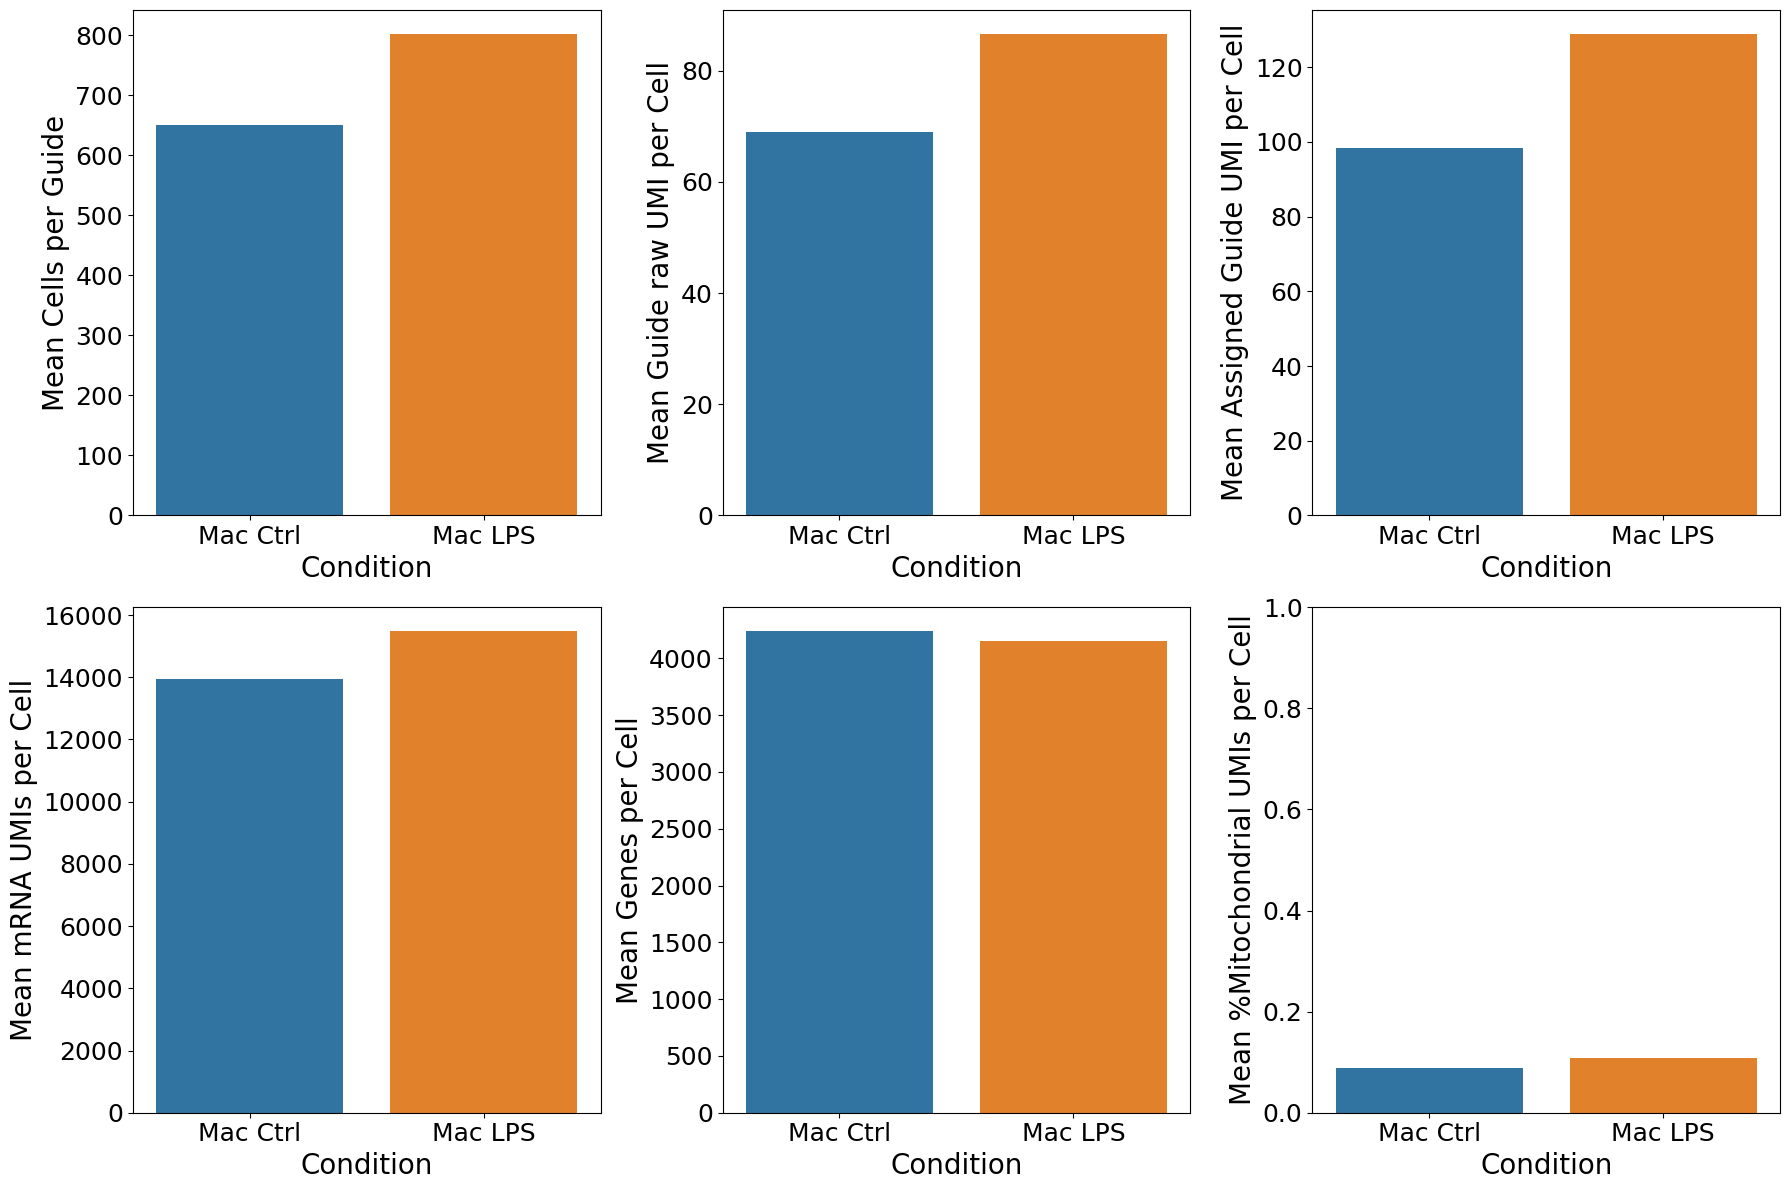

In [431]:
fig, ax = plt.subplots(2,3, figsize = (18,12))
ax = ax.flatten()
titles = ["Mean Cells per Guide", "Mean Guide raw UMI per Cell", "Mean Assigned Guide UMI per Cell", 
          "Mean mRNA UMIs per Cell", "Mean Genes per Cell", "Mean %Mitochondrial UMIs per Cell"]
sns.barplot(
    df_combined,
    x = 'condition',
    y = 'mean_cells_per_guide',
    hue="condition",
    ax = ax[0]
)
sns.barplot(
    df_combined,
    x = 'condition',
    y = 'avg_sgrna_umi_per_cell',
    hue="condition",
    ax = ax[1]
)
sns.barplot(
    df_combined,
    x = 'condition',
    y = 'mean_sgRNA_assigned_UMI',
    hue="condition",
    ax = ax[2]
)
sns.barplot(
    df_combined,
    x = 'condition',
    y = 'mean_UMI',
    hue="condition",
    ax = ax[3]
)
sns.barplot(
    df_combined,
    x = 'condition',
    y = 'mean_genes',
    hue="condition",
    ax = ax[4]
)
sns.barplot(
    df_combined,
    x = 'condition',
    y = 'mean_mito',
    hue="condition",
    ax = ax[5]
)
ax[5].set_ylim([0, 1])
for i, title in enumerate(titles):
    ax[i].set_ylabel(title, fontsize=20)
    ax[i].tick_params(axis='both', which='major', labelsize=18)
    ax[i].set_xlabel("Condition", fontsize=20)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig(os.path.join(plt_path, "QC_data_for_all_condition.pdf"), dpi = 300)